# ViTPose Prototyping

This notebook tests the zero-shot performance of ViTPose (via `easy_ViTPose`) on cropped swimmer images to ensure it can robustly track the center of the hips underwater.

In [1]:
import cv2
import os
import glob
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import PIL.Image

# Transformers for ViTPose
from transformers import AutoProcessor, VitPoseForPoseEstimation

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [2]:
# 1. Initialize YOLO (for finding the swimmer bounding box)
# Since the custom marker detection model no longer detects the swimmer,
# we use a standard pre-trained YOLOv8 model to detect the 'person' class (cls 0)
try:
    yolo_model = YOLO("yolov8s.pt") 
    print("Pre-trained YOLOv8 for person detection loaded")
except Exception as e:
    print(f"Failed to load YOLO: {e}")

# 2. Initialize ViTPose Inference via HuggingFace Transformers
try:
    pose_model_name = "usyd-community/vitpose-plus-large"
    pose_image_processor = AutoProcessor.from_pretrained(pose_model_name)
    pose_model = VitPoseForPoseEstimation.from_pretrained(pose_model_name, device_map=device)
    print("Transformers ViTPose Model Loaded!")
except Exception as e:
    print(f"Error loading ViTPose: {e}")

Pre-trained YOLOv8 for person detection loaded


The image processor of type `VitPoseImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/691 [00:00<?, ?it/s]

Transformers ViTPose Model Loaded!


Found 6156 frames.


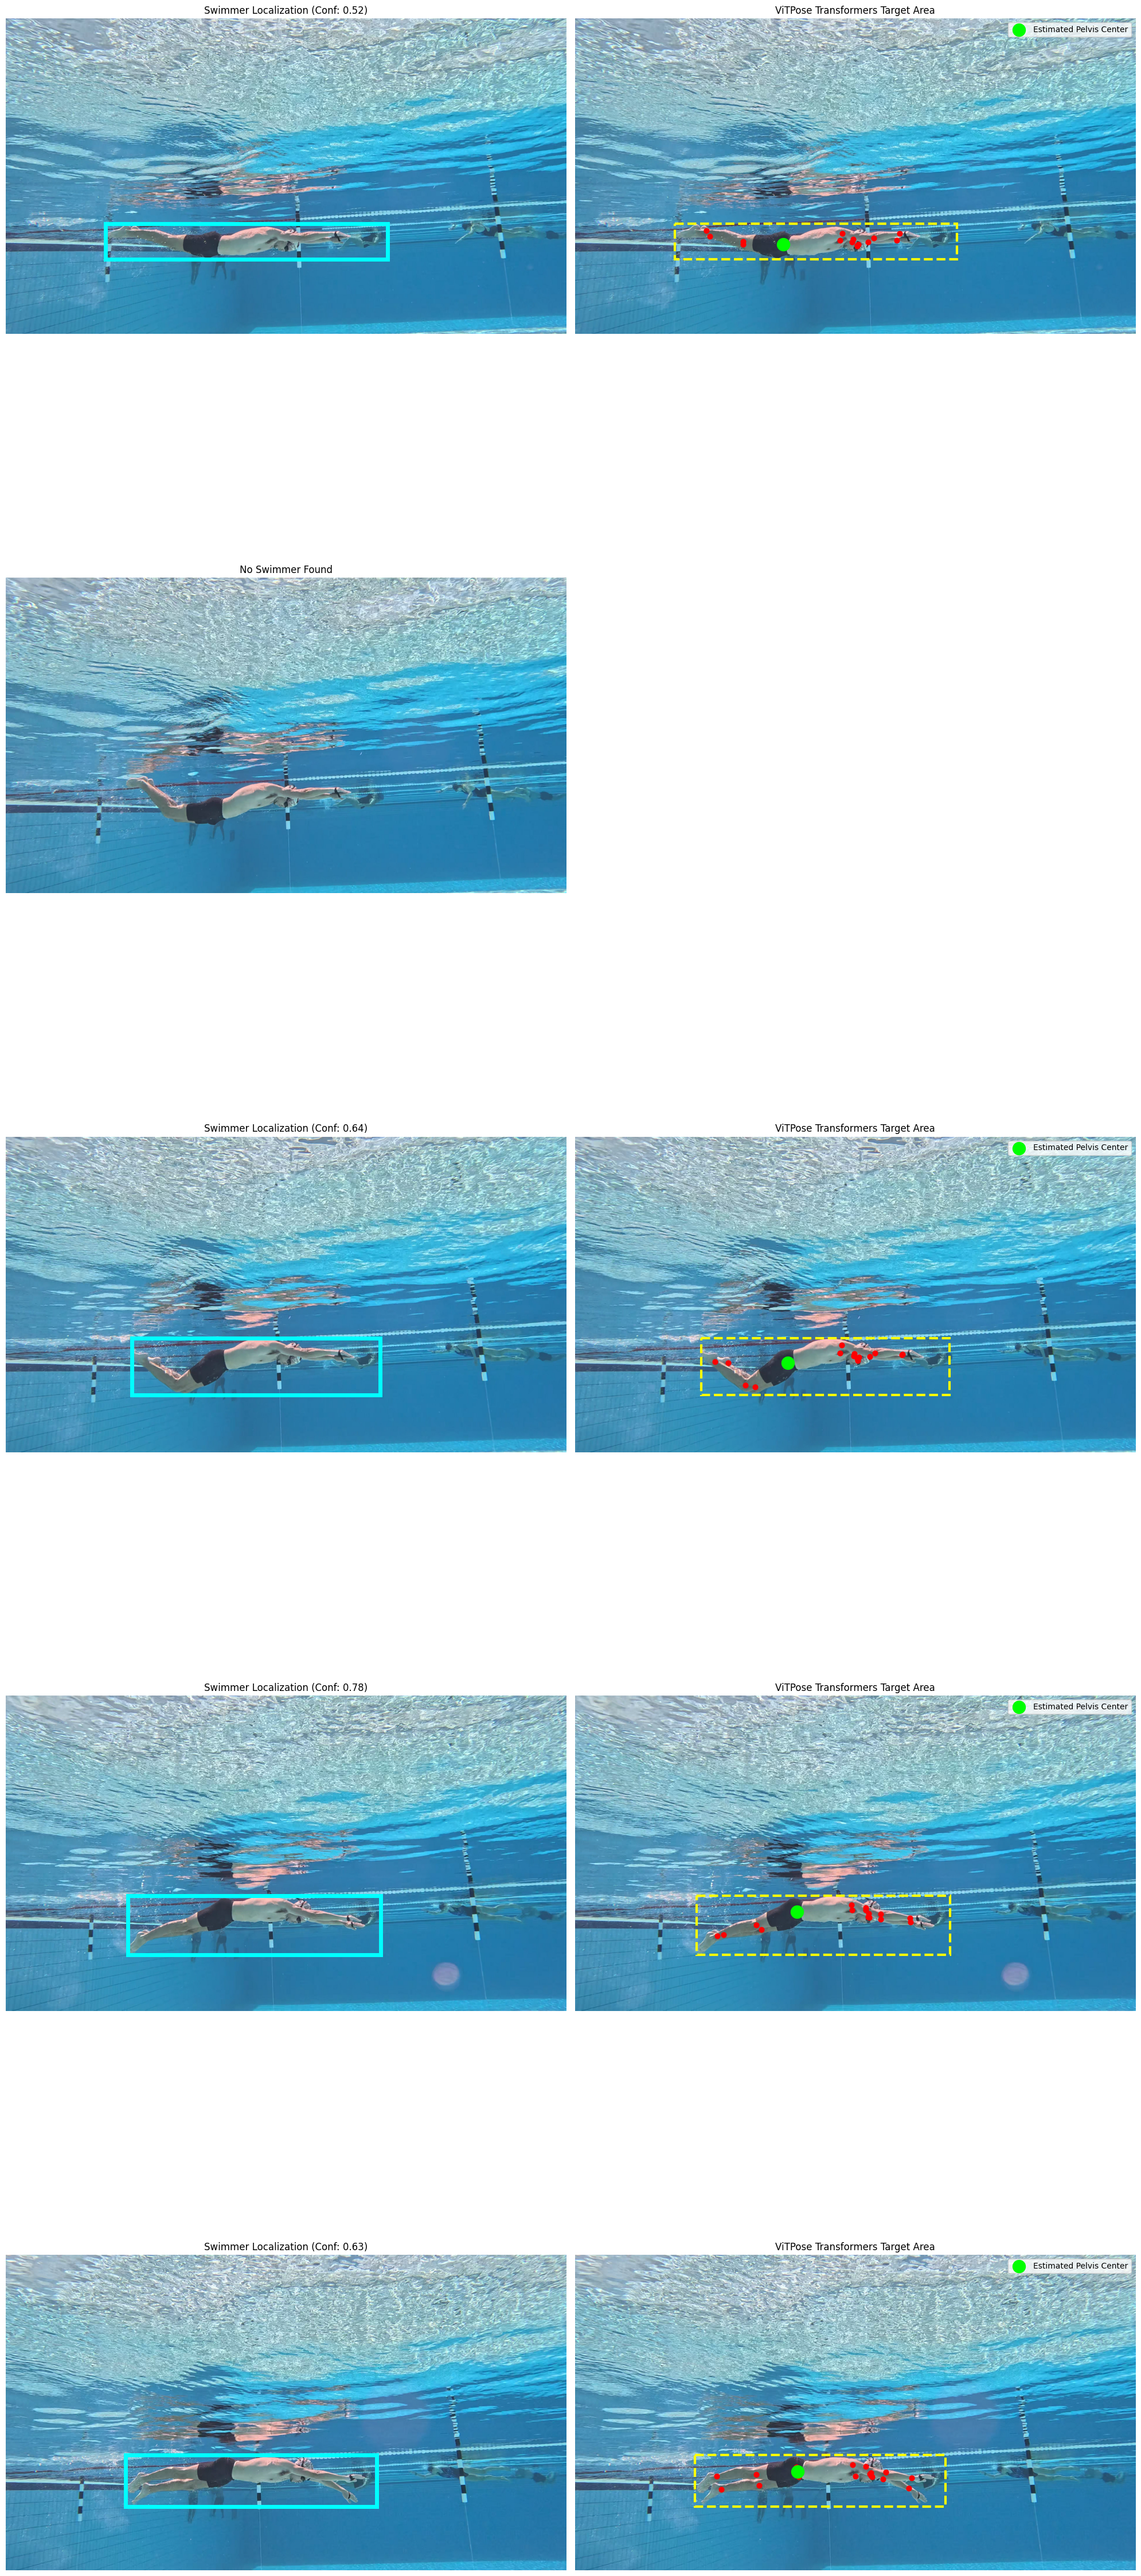

In [3]:
# 3. Test on a pool of sample frames
# Let's use the folder that is definitively underwater freestyle footage
FRAMES_DIR = "frames/under/Bottom_Freestyle_P034/"

frame_paths = sorted(
    glob.glob(os.path.join(FRAMES_DIR, "*.jpg")) +
    glob.glob(os.path.join(FRAMES_DIR, "*.jpeg")),
    key=lambda p: int(''.join(filter(str.isdigit, os.path.splitext(os.path.basename(p))[0])))
)
print(f"Found {len(frame_paths)} frames.")

# Select ~5 frames deeper into the video where the swimmer is likely in frame
sample_frames = frame_paths[1000:1100:20] if len(frame_paths) > 600 else frame_paths[:5]

fig, axes = plt.subplots(len(sample_frames), 2, figsize=(20, 10 * len(sample_frames)))

for idx, p in enumerate(sample_frames):
    img = cv2.imread(p)
    if img is None:
        print(f"Could not read {p}")
        continue
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_img = PIL.Image.fromarray(img_rgb)
    
    # Run YOLO to find the swimmer (person class is 0 in COCO)
    results = yolo_model(img_rgb, verbose=False)
    
    swimmer_box = None
    best_conf = -1.0
    for det in results[0].boxes.data.cpu().numpy():
        x1, y1, x2, y2, conf, cls = det
        if int(cls) == 0 and conf > best_conf: # person class
            swimmer_box = [int(x1), int(y1), int(x2), int(y2)]
            best_conf = conf
            
    if swimmer_box is None:
        axes[idx, 0].imshow(img_rgb)
        axes[idx, 0].set_title(f"No Swimmer Found")
        axes[idx, 0].axis('off')
        axes[idx, 1].axis('off')
        continue
        
    x1, y1, x2, y2 = swimmer_box
    
    # Draw swimmer bounding box locally
    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='cyan', linewidth=5))
    axes[idx, 0].set_title(f"Swimmer Localization (Conf: {best_conf:.2f})")
    axes[idx, 0].axis('off')
    
    # ViTPose transformers expects boxes in COCO format (x, y, w, h)
    bbox_w = x2 - x1
    bbox_h = y2 - y1
    person_boxes = np.array([[x1, y1, bbox_w, bbox_h]])
    
    # Run ViTPose exactly on the detected bounding box
    inputs = pose_image_processor(pil_img, boxes=[person_boxes], return_tensors="pt").to(device)

    # for vitpose-plus-base checkpoint we should additionally provide dataset_index
    # to specify which MOE experts to use for inference
    if pose_model.config.backbone_config.num_experts > 1:
        dataset_index = torch.tensor([0] * len(inputs["pixel_values"])).to(device)
        inputs["dataset_index"] = dataset_index

    with torch.no_grad():
        outputs = pose_model(**inputs)
    
    pose_results = pose_image_processor.post_process_pose_estimation(outputs, boxes=[person_boxes])
    image_pose_result = pose_results[0]  # results for first image
    
    # Render ViTPose outputs back onto the original frame coordinates
    axes[idx, 1].imshow(img_rgb)
    axes[idx, 1].add_patch(plt.Rectangle((x1, y1), bbox_w, bbox_h, fill=False, color='yellow', linewidth=3, linestyle='--'))
    
    if len(image_pose_result) > 0:
        person_pose = image_pose_result[0]
        kpts = person_pose["keypoints"].cpu().numpy()
        scores = person_pose["scores"].cpu().numpy()
        
        # Plot all keypoints for visualization/debugging exactly over the crop area
        for j, (kp, score) in enumerate(zip(kpts, scores)):
            if score > 0.1:
                axes[idx, 1].scatter([kp[0]], [kp[1]], color='red', s=40)

        # Plot exact Hips (COCO: 11 = Left Hip, 12 = Right Hip)
        try:
            if len(kpts) > 12 and scores[11] > 0.1 and scores[12] > 0.1: 
                lh = kpts[11]
                rh = kpts[12]
                
                hip_cx = (lh[0] + rh[0]) / 2
                hip_cy = (lh[1] + rh[1]) / 2
                
                axes[idx, 1].scatter([hip_cx], [hip_cy], color='lime', s=250, zorder=5, label='Estimated Pelvis Center')
                axes[idx, 1].legend(loc='upper right')
        except IndexError:
            pass
            
    axes[idx, 1].set_title(f"ViTPose Transformers Target Area")
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# 4. Process entire sequence into a Video
import tqdm
from IPython.display import clear_output

OUTPUT_VIDEO_PATH = "output/vitpose_freestyle_p034.mp4"
os.makedirs("output", exist_ok=True)

# Tracking metrics
total_frames = len(frame_paths)
swimmer_detected_count = 0
vitpose_detected_count = 0
hips_detected_count = 0

if total_frames == 0:
    print("No frames found!")
else:
    # Read first frame to get dimensions
    sample_img = cv2.imread(frame_paths[0])
    h, w = sample_img.shape[:2]
    fps = 60 

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out_writer = cv2.VideoWriter(OUTPUT_VIDEO_PATH, fourcc, fps, (w, h))

    print(f"Processing {total_frames} frames for video output...")
    
    for i, p in enumerate(frame_paths):
        if i % 100 == 0:
            print(f"Processing frame {i}/{total_frames}...")
            
        img = cv2.imread(p)
        if img is None: continue
        
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        pil_img = PIL.Image.fromarray(img_rgb)
        
        # YOLO - using standard pretrained to find a person (cls 0)
        results = yolo_model(img_rgb, verbose=False)
        swimmer_box = None
        best_conf = -1.0
        for det in results[0].boxes.data.cpu().numpy():
            x1, y1, x2, y2, conf, cls = det
            if int(cls) == 0 and conf > best_conf: # person class 0
                swimmer_box = [int(x1), int(y1), int(x2), int(y2)]
                best_conf = conf

        out_frame = img.copy()

        if swimmer_box is not None:
            swimmer_detected_count += 1
            x1, y1, x2, y2 = swimmer_box
            
            bbox_w = x2 - x1
            bbox_h = y2 - y1
            
            person_boxes = np.array([[x1, y1, bbox_w, bbox_h]])
            
            inputs = pose_image_processor(pil_img, boxes=[person_boxes], return_tensors="pt").to(device)
            
            if pose_model.config.backbone_config.num_experts > 1:
                dataset_index = torch.tensor([0] * len(inputs["pixel_values"])).to(device)
                inputs["dataset_index"] = dataset_index

            with torch.no_grad():
                outputs = pose_model(**inputs)
            
            pose_results = pose_image_processor.post_process_pose_estimation(outputs, boxes=[person_boxes])
            
            # Draw Swimmer Box
            cv2.rectangle(out_frame, (x1, y1), (x2, y2), (255, 255, 0), 5) # Cyan-ish in BGR

            if len(pose_results) > 0 and len(pose_results[0]) > 0:
                vitpose_detected_count += 1
                person_pose = pose_results[0][0]
                kpts = person_pose["keypoints"].cpu().numpy()
                scores = person_pose["scores"].cpu().numpy()
                
                # Draw points (BGR color space: Red is (0, 0, 255))
                for kp, score in zip(kpts, scores):
                    if score > 0.1:
                        cv2.circle(out_frame, (int(kp[0]), int(kp[1])), 6, (0, 0, 255), -1) 
                        
                # Draw Hips Center
                if len(kpts) > 12 and scores[11] > 0.1 and scores[12] > 0.1:
                    hips_detected_count += 1
                    lh = kpts[11]
                    rh = kpts[12]
                    hip_cx = int((lh[0] + rh[0]) / 2)
                    hip_cy = int((lh[1] + rh[1]) / 2)
                    cv2.circle(out_frame, (hip_cx, hip_cy), 15, (0, 255, 0), -1) # Green
        
        out_writer.write(out_frame)
        
    out_writer.release()
    print(f"Done! Video saved to {OUTPUT_VIDEO_PATH}")

Processing 6156 frames for video output...
Processing frame 0/6156...
Processing frame 100/6156...
Processing frame 200/6156...
Processing frame 300/6156...
Processing frame 400/6156...
Processing frame 500/6156...
Processing frame 600/6156...
Processing frame 700/6156...
Processing frame 800/6156...
Processing frame 900/6156...
Processing frame 1000/6156...
Processing frame 1100/6156...
Processing frame 1200/6156...
Processing frame 1300/6156...
Processing frame 1400/6156...
Processing frame 1500/6156...
Processing frame 1600/6156...
Processing frame 1700/6156...


Corrupt JPEG data: 38 extraneous bytes before marker 0xd9


Processing frame 1800/6156...
Processing frame 1900/6156...
Processing frame 2000/6156...
Processing frame 2100/6156...
Processing frame 2200/6156...
Processing frame 2300/6156...
Processing frame 2400/6156...
Processing frame 2500/6156...
Processing frame 2600/6156...
Processing frame 2700/6156...
Processing frame 2800/6156...
Processing frame 2900/6156...
Processing frame 3000/6156...
Processing frame 3100/6156...
Processing frame 3200/6156...
Processing frame 3300/6156...
Processing frame 3400/6156...
Processing frame 3500/6156...
Processing frame 3600/6156...
Processing frame 3700/6156...
Processing frame 3800/6156...
Processing frame 3900/6156...
Processing frame 4000/6156...
Processing frame 4100/6156...
Processing frame 4200/6156...
Processing frame 4300/6156...
Processing frame 4400/6156...
Processing frame 4500/6156...
Processing frame 4600/6156...
Processing frame 4700/6156...
Processing frame 4800/6156...
Processing frame 4900/6156...
Processing frame 5000/6156...
Processing

Total Frames Processed: 6156
Swimmer Detected (YOLO): 3609 (58.63%)
Pose Detected (ViTPose): 3609 (58.63%)
Hips Detected (ViTPose): 3578 (58.12%)


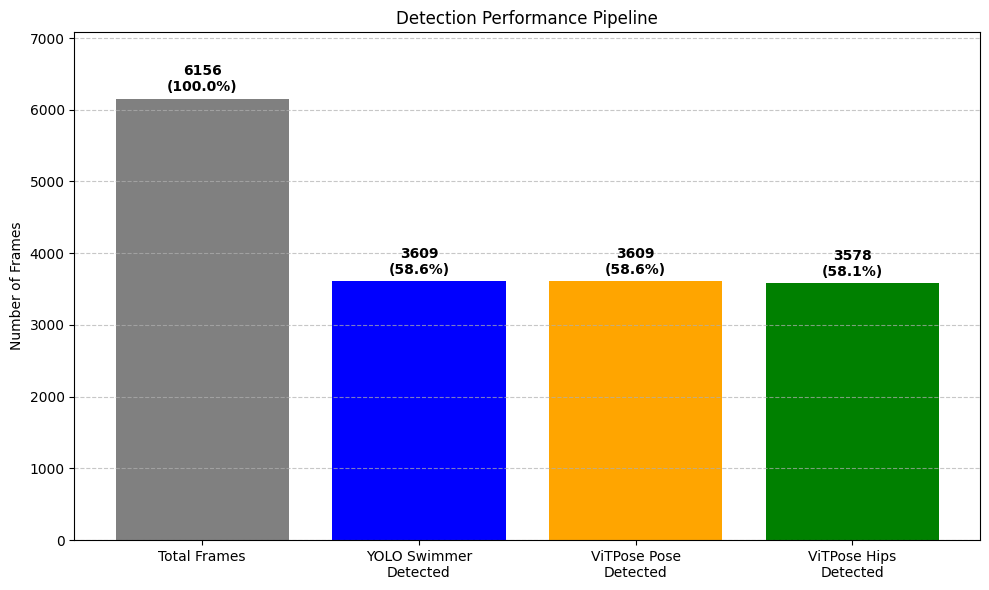

In [5]:
# 5. Detection Statistics
import matplotlib.pyplot as plt

print(f"Total Frames Processed: {total_frames}")
print(f"Swimmer Detected (YOLO): {swimmer_detected_count} ({swimmer_detected_count/total_frames*100:.2f}%)")
print(f"Pose Detected (ViTPose): {vitpose_detected_count} ({vitpose_detected_count/total_frames*100:.2f}%)")
print(f"Hips Detected (ViTPose): {hips_detected_count} ({hips_detected_count/total_frames*100:.2f}%)")

# Create a bar chart
labels = ['Total Frames', 'YOLO Swimmer\nDetected', 'ViTPose Pose\nDetected', 'ViTPose Hips\nDetected']
counts = [total_frames, swimmer_detected_count, vitpose_detected_count, hips_detected_count]
colors = ['gray', 'blue', 'orange', 'green']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, counts, color=colors)

# Add percentage labels on top of the bars
for i, bar in enumerate(bars):
    yval = bar.get_height()
    percentage = (counts[i] / total_frames) * 100
    plt.text(bar.get_x() + bar.get_width()/2, yval + (total_frames * 0.01), 
             f'{counts[i]}\n({percentage:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.title('Detection Performance Pipeline')
plt.ylabel('Number of Frames')
plt.ylim(0, total_frames * 1.15) # Leave room for labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()